<a href="https://colab.research.google.com/github/AditiNayak-S/MLT3011_Cloud-Infrastructure-Failure-Prediction/blob/main/notebooks/Machine_LearningTechniques_Lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Techniques

## Lab 4: Logistic Regression and Decision Tree Classification


### Lab Objectives

- Prepare a cloud infrastructure monitoring dataset for binary classification.
- Implement Logistic Regression and Decision Tree classification models.
- Compare the performance of both classifiers.
- Evaluate the models using multiple classification metrics.
- Visualize and interpret the classification results.

## Importing Required Libraries

The following libraries are required for data manipulation, feature engineering, visualization, classification, and model evaluation.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import zipfile

from google.colab import files

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
uploaded = files.upload()uploaded_files = list(uploaded.keys())

for file in uploaded_files:
    print(file)

Saving CIFPS - DATASET A.zip to CIFPS - DATASET A.zip
Saving CIFPS - DATASET B.zip to CIFPS - DATASET B.zip


In [ ]:
uploaded_files = list(uploaded.keys())

for file in uploaded_files:
    print(file)

CIFPS - DATASET A.zip
CIFPS - DATASET B.zip


In [ ]:
for file in uploaded_files:
    with zipfile.ZipFile(file,"r") as zip_ref:
        zip_ref.extractall()

print("Extraction completed.")

Extraction completed.


In [ ]:
DATASET_A_PATH = "cloud-monitoring-dataset-master/data"

selected_dataset = os.path.join(
    DATASET_A_PATH,
    "application-crash-rate-1",
    "app1-02.csv"
)

raw_df = pd.read_csv(selected_dataset)

display(raw_df.head())

,TimeStamp,Value,Label
0,2018-06-19 00:00:00,7,0
1,2018-06-19 01:00:00,6,0
2,2018-06-19 02:00:00,6,0
3,2018-06-19 03:00:00,9,0
4,2018-06-19 04:00:00,4,0


## Data Preparation

The timestamp attribute is converted into a datetime format and transformed into numerical temporal features suitable for machine learning. These engineered features are then used for binary classification.

In [ ]:
model_df = raw_df.copy()

model_df["TimeStamp"] = pd.to_datetime(model_df["TimeStamp"])

model_df["Hour"] = model_df["TimeStamp"].dt.hour
model_df["Minute"] = model_df["TimeStamp"].dt.minute
model_df["Second"] = model_df["TimeStamp"].dt.second
model_df["DayOfWeek"] = model_df["TimeStamp"].dt.dayofweek
model_df["IsWeekend"] = model_df["DayOfWeek"].isin([5,6]).astype(int)

model_df.drop(columns=["TimeStamp"], inplace=True)

display(model_df.head())

,Value,Label,Hour,Minute,Second,DayOfWeek,IsWeekend
0,7,0,0,0,0,1,0
1,6,0,1,0,0,1,0
2,6,0,2,0,0,1,0
3,9,0,3,0,0,1,0
4,4,0,4,0,0,1,0


## Logistic Regression Classification

Logistic Regression predicts the probability of an application failure using a logistic function. It is one of the most widely used supervised learning algorithms for binary classification problems.

In [ ]:
X = model_df.drop(columns=["Label"])

y = model_df["Label"]

display(X.head())
display(y.head())

,Value,Hour,Minute,Second,DayOfWeek,IsWeekend
0,7,0,0,0,1,0
1,6,1,0,0,1,0
2,6,2,0,0,1,0
3,9,3,0,0,1,0
4,4,4,0,0,1,0


,Label
0,0
1,0
2,0
3,0
4,0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
logistic_model = LogisticRegression(
    max_iter=1000
)

logistic_model.fit(
    X_train,
    y_train
)

logistic_predictions = logistic_model.predict(X_test)

logistic_probabilities = logistic_model.predict_proba(X_test)[:,1]

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


## Decision Tree Classification

The Decision Tree classifier learns decision rules from historical cloud monitoring observations to classify application behaviour as either normal or failure.

In [ ]:
tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_model.fit(
    X_train,
    y_train
)

tree_predictions = tree_model.predict(X_test)

tree_probabilities = tree_model.predict_proba(X_test)[:,1]

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [ ]:
plt.style.use("dark_background")

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["font.size"] = 11

print("Visualization theme configured successfully.")

Visualization theme configured successfully.


## Model Evaluation

The Logistic Regression and Decision Tree classifiers are evaluated using multiple classification metrics. These metrics provide a quantitative comparison of each model's predictive performance for identifying cloud application failures.

In [ ]:
logistic_accuracy = accuracy_score(y_test, logistic_predictions)
logistic_precision = precision_score(y_test, logistic_predictions)
logistic_recall = recall_score(y_test, logistic_predictions)
logistic_f1 = f1_score(y_test, logistic_predictions)
logistic_auc = roc_auc_score(y_test, logistic_probabilities)

tree_accuracy = accuracy_score(y_test, tree_predictions)
tree_precision = precision_score(y_test, tree_predictions)
tree_recall = recall_score(y_test, tree_predictions)
tree_f1 = f1_score(y_test, tree_predictions)
tree_auc = roc_auc_score(y_test, tree_probabilities)

evaluation = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Logistic Regression":[
        logistic_accuracy,
        logistic_precision,
        logistic_recall,
        logistic_f1,
        logistic_auc
    ],
    "Decision Tree":[
        tree_accuracy,
        tree_precision,
        tree_recall,
        tree_f1,
        tree_auc
    ]
})

evaluation.iloc[:,1:] = evaluation.iloc[:,1:].round(4)

display(evaluation)

,Metric,Logistic Regression,Decision Tree
0,Accuracy,0.9366,0.9437
1,Precision,1.0000,1.0000
2,Recall,0.5263,0.5789
3,F1 Score,0.6897,0.7333
4,ROC-AUC,0.9046,0.8699


## ROC Curve Comparison

The Receiver Operating Characteristic (ROC) Curve compares the ability of both classification models to distinguish between normal and failure events. A curve closer to the upper-left corner indicates better classification performance.

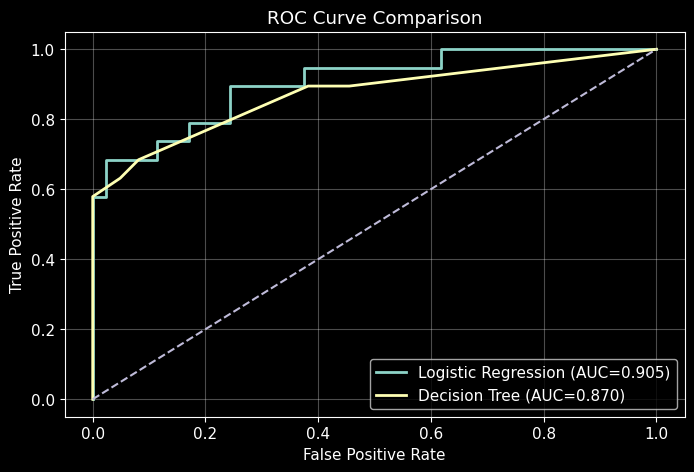

In [ ]:
fpr_log, tpr_log, _ = roc_curve(
    y_test,
    logistic_probabilities
)

fpr_tree, tpr_tree, _ = roc_curve(
    y_test,
    tree_probabilities
)

plt.figure()

plt.plot(
    fpr_log,
    tpr_log,
    linewidth=2,
    label=f"Logistic Regression (AUC={logistic_auc:.3f})"
)

plt.plot(
    fpr_tree,
    tpr_tree,
    linewidth=2,
    label=f"Decision Tree (AUC={tree_auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.title("ROC Curve Comparison")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

## Confusion Matrix - Logistic Regression

The confusion matrix summarizes the prediction outcomes of the Logistic Regression classifier by comparing the actual application status with the predicted status.

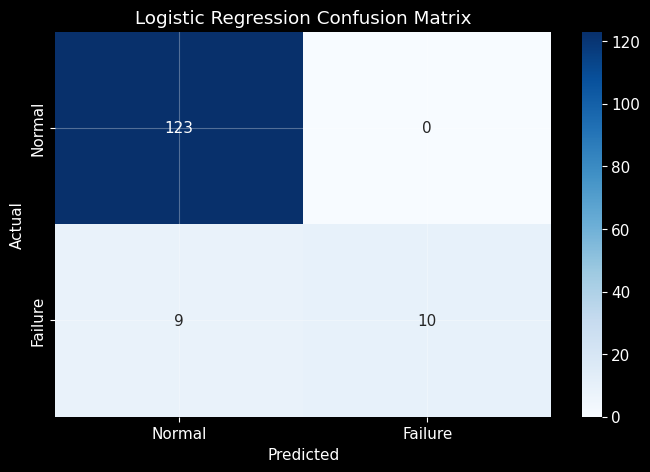

In [ ]:
log_cm = confusion_matrix(
    y_test,
    logistic_predictions
)

sns.heatmap(
    log_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal","Failure"],
    yticklabels=["Normal","Failure"]
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## Confusion Matrix - Decision Tree

The confusion matrix summarizes the prediction outcomes of the Decision Tree classifier by comparing the actual application status with the predicted status.

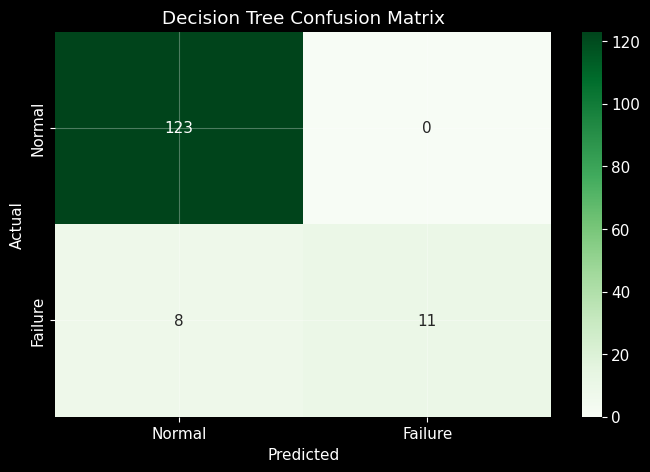

In [ ]:
tree_cm = confusion_matrix(
    y_test,
    tree_predictions
)

sns.heatmap(
    tree_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Normal","Failure"],
    yticklabels=["Normal","Failure"]
)

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## Decision Tree Structure

The Decision Tree visualization illustrates the sequence of decision rules learned from the cloud monitoring dataset. Each internal node represents a decision based on an input feature, while each leaf node represents the predicted application status.

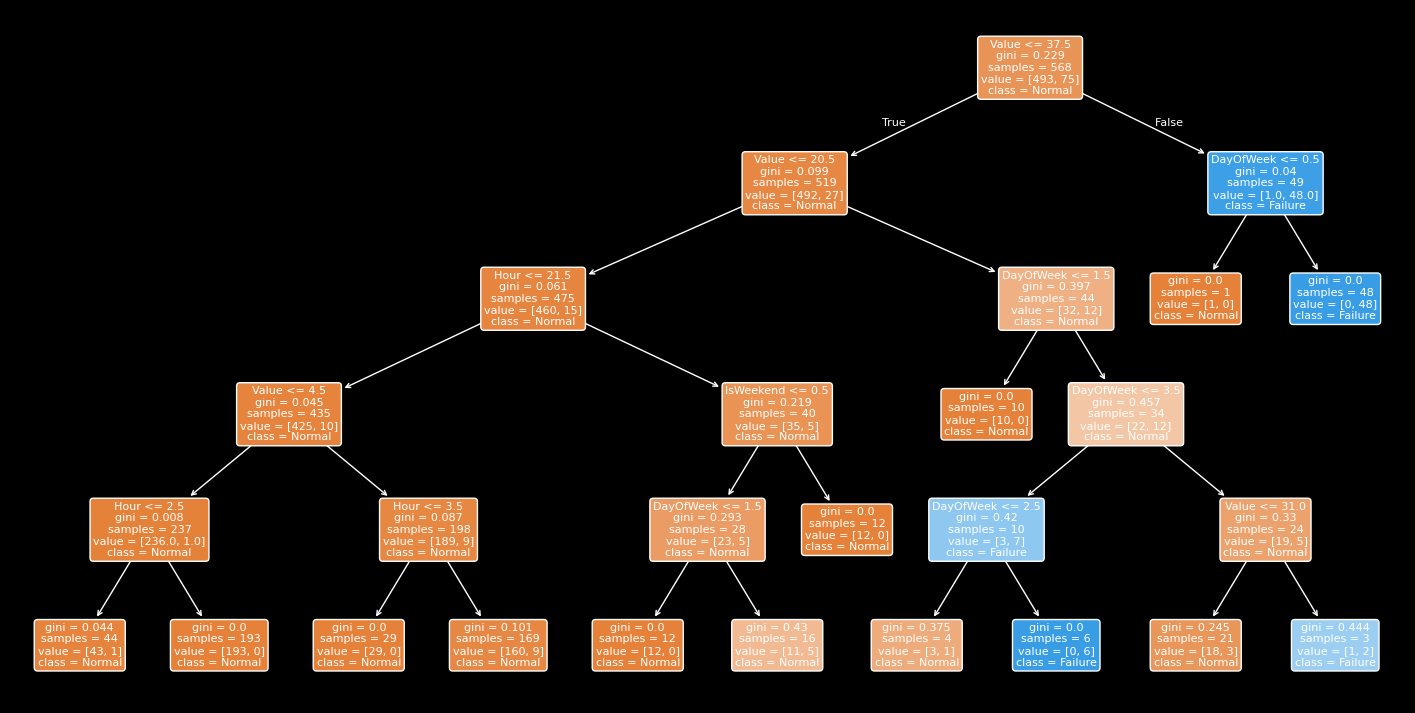

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,9))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["Normal","Failure"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

## Performance Comparison of Classification Models

The following visualization compares the overall performance of Logistic Regression and Decision Tree classifiers using multiple evaluation metrics. This comparison helps identify the model that performs better for cloud infrastructure failure prediction.

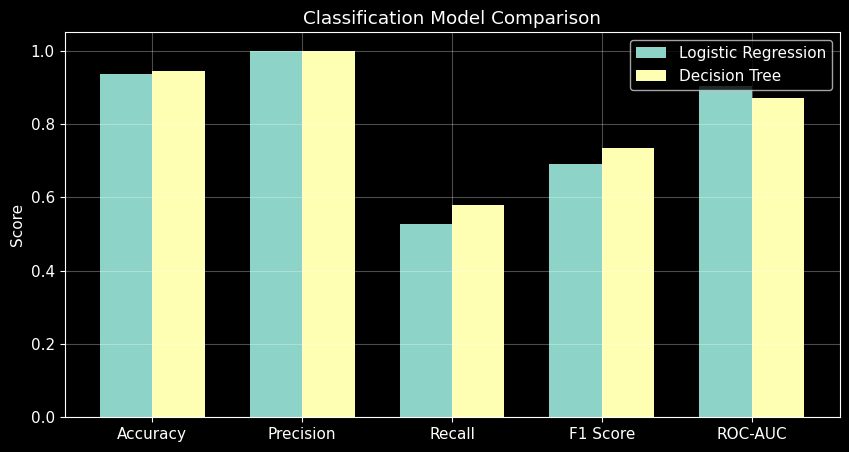

In [ ]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

x = np.arange(len(metrics))

width = 0.35

plt.figure(figsize=(10,5))

plt.bar(
    x-width/2,
    evaluation["Logistic Regression"],
    width,
    label="Logistic Regression"
)

plt.bar(
    x+width/2,
    evaluation["Decision Tree"],
    width,
    label="Decision Tree"
)

plt.xticks(x, metrics)

plt.ylabel("Score")

plt.title("Classification Model Comparison")

plt.legend()

plt.show()

## Best Model Selection

The performance of Logistic Regression and Decision Tree classifiers is compared using multiple evaluation metrics. Based on the comparative analysis, the classifier with the stronger predictive capability is identified for the cloud infrastructure failure prediction task.

In [ ]:
comparison_metric = "ROC-AUC"

if tree_auc > logistic_auc:
    best_model = "Decision Tree"
    reason = "It achieved a higher ROC-AUC score, indicating better classification capability."
elif logistic_auc > tree_auc:
    best_model = "Logistic Regression"
    reason = "It achieved a higher ROC-AUC score, indicating better classification capability."
else:
    best_model = "Both Models"
    reason = "Both models achieved identical ROC-AUC scores."

best_model_summary = pd.DataFrame({
    "Selection Criterion": [comparison_metric],
    "Selected Model": [best_model],
    "Reason": [reason]
})

display(best_model_summary)

,Selection Criterion,Selected Model,Reason
0,ROC-AUC,Logistic Regression,"It achieved a higher ROC-AUC score, indicating..."


## Model Interpretation

Both classification algorithms successfully learned patterns from the cloud monitoring dataset to distinguish between normal and failure events. Logistic Regression models the probability of failure using a linear decision boundary, whereas the Decision Tree classifier captures rule-based relationships within the data. The comparative evaluation demonstrates the strengths of both approaches and highlights the model that is more suitable for this cloud infrastructure failure prediction dataset.

## Key Observations

- The cloud monitoring dataset was successfully prepared for binary classification.
- Logistic Regression and Decision Tree classifiers were implemented on the same training and testing datasets.
- Model performance was evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
- ROC Curve and Confusion Matrix visualizations provided additional insight into classification performance.
- Comparative evaluation identified the classifier with better predictive capability for the selected dataset.
- The experiment demonstrates the importance of evaluating multiple machine learning algorithms before selecting a final model.

## Conclusion

In this laboratory experiment, Logistic Regression and Decision Tree classifiers were successfully implemented using a real-world cloud infrastructure monitoring dataset. The dataset was preprocessed through temporal feature engineering and used to train both classification models. Their predictive performance was compared using multiple evaluation metrics and visualization techniques, including ROC Curves and Confusion Matrices. The comparative analysis enabled the identification of the better-performing classifier for cloud infrastructure failure prediction, thereby achieving the objective of evaluating and comparing supervised classification algorithms.

In [ ]:
completion_checklist = pd.DataFrame({
    "Task": [
        "Imported required libraries",
        "Uploaded and extracted datasets",
        "Prepared classification dataset",
        "Performed feature engineering",
        "Implemented Logistic Regression",
        "Implemented Decision Tree",
        "Generated predictions",
        "Evaluated both models",
        "Generated classification visualizations",
        "Compared classifier performance",
        "Selected the best-performing model",
        "Completed experiment"
    ],
    "Status": ["✓ Completed"] * 12
})

display(completion_checklist)

,Task,Status
0,Imported required libraries,✓ Completed
1,Uploaded and extracted datasets,✓ Completed
2,Prepared classification dataset,✓ Completed
3,Performed feature engineering,✓ Completed
4,Implemented Logistic Regression,✓ Completed
5,Implemented Decision Tree,✓ Completed
6,Generated predictions,✓ Completed
7,Evaluated both models,✓ Completed
8,Generated classification visualizations,✓ Completed
9,Compared classifier performance,✓ Completed


In [ ]:
print("           LOGISTIC REGRESSION vs DECISION TREE - LAB SUMMARY")


print(f"Dataset Used                  : {os.path.basename(selected_dataset)}")
print(f"Total Records                 : {len(model_df)}")
print(f"Training Samples              : {len(X_train)}")
print(f"Testing Samples               : {len(X_test)}")

print("\nLogistic Regression")
print(f"Accuracy                      : {logistic_accuracy:.4f}")
print(f"Precision                     : {logistic_precision:.4f}")
print(f"Recall                        : {logistic_recall:.4f}")
print(f"F1 Score                      : {logistic_f1:.4f}")
print(f"ROC-AUC                       : {logistic_auc:.4f}")

print("\nDecision Tree")
print(f"Accuracy                      : {tree_accuracy:.4f}")
print(f"Precision                     : {tree_precision:.4f}")
print(f"Recall                        : {tree_recall:.4f}")
print(f"F1 Score                      : {tree_f1:.4f}")
print(f"ROC-AUC                       : {tree_auc:.4f}")

print("\nBest Performing Model         :", best_model)
print("Reason                        :", reason)

print("\nStatus : LAB 4 COMPLETED SUCCESSFULLY")


           LOGISTIC REGRESSION vs DECISION TREE - LAB SUMMARY
Dataset Used                  : app1-02.csv
Total Records                 : 710
Training Samples              : 568
Testing Samples               : 142

Logistic Regression
Accuracy                      : 0.9366
Precision                     : 1.0000
Recall                        : 0.5263
F1 Score                      : 0.6897
ROC-AUC                       : 0.9046

Decision Tree
Accuracy                      : 0.9437
Precision                     : 1.0000
Recall                        : 0.5789
F1 Score                      : 0.7333
ROC-AUC                       : 0.8699

Best Performing Model         : Logistic Regression
Reason                        : It achieved a higher ROC-AUC score, indicating better classification capability.

Status : LAB 4 COMPLETED SUCCESSFULLY
